In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import string
import IPython.display as display

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ruta= "/content/drive/MyDrive/Proyecto de profundización 1/PROYECTO GRADO 2025/Resultados modelos/canciones_clasificacion_polaridad_IA.xlsx"
df = pd.read_excel(ruta, sheet_name = "Sheet1")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3721 entries, 0 to 3720
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   TITULO            3721 non-null   object
 1   AÑO               3721 non-null   int64 
 2   COMPOSITOR        3721 non-null   object
 3   UBICACIÓN         3721 non-null   object
 4   DEPARTAMENTO      3721 non-null   object
 5   URL               3721 non-null   object
 6   GENERO            3721 non-null   object
 7   AUDIO_NAME        3721 non-null   object
 8   LETRA             3721 non-null   object
 9   AUDIO_DESCARGADO  3721 non-null   bool  
 10  POLARIDAD         3721 non-null   object
dtypes: bool(1), int64(1), object(9)
memory usage: 294.5+ KB


In [ ]:
def informe(df: pd.DataFrame) -> pd.DataFrame:
    desc = []

    for i, col in enumerate(df.columns):
        serie = df[col]

        non_null = serie.notnull().sum()
        nulls = serie.isnull().sum()
        distinct = serie.nunique(dropna=True)

        if not serie.dropna().empty: top_val = serie.mode().iloc[0]
        else: top_val = None
        fq = (serie == top_val).sum()

        desc.append({"Columna": col, "Tipo": str(serie.dtype), "Valores": non_null, "Nulos": nulls, "Distintos": distinct,
                     "mas frecuente": top_val, "frecuencia":fq})

    return pd.DataFrame(desc)

In [ ]:
informe(df)

,Columna,Tipo,Valores,Nulos,Distintos,mas frecuente,frecuencia
0,TITULO,object,3721,0,3538,DIME,5
1,AÑO,int64,3721,0,34,1990,141
2,COMPOSITOR,object,3721,0,309,DARIO DE JESUS GOMEZ ZAPATA,132
3,UBICACIÓN,object,3721,0,70,BOGOTA D.C.,1550
4,DEPARTAMENTO,object,3721,0,25,BOGOTA D.C.,1550
5,URL,object,3721,0,3625,https://www.youtube.com/watch?v=37UlOp_LzIA,3
6,GENERO,object,3721,0,63,VALLENATO,498
7,AUDIO_NAME,object,3721,0,3680,AMOR_2020_POLIKARPA Y SUS VICIOSAS,3
8,LETRA,object,3721,0,3652,desorden social presenta nada que callar Bienv...,13
9,AUDIO_DESCARGADO,bool,3721,0,2,True,3575


In [ ]:
# Filtrar quitando ese compositor
df = df[df["COMPOSITOR"].str.upper() != "JUAN MANUEL MORENO AVENDAÑO"]

In [ ]:
# Crear la columna llave
df.insert(0, "LLAVE", df["TITULO"].astype(str) + "_" + df["AÑO"].astype(str) + "_" + df["COMPOSITOR"].astype(str))
df.head()

,LLAVE,TITULO,AÑO,COMPOSITOR,UBICACIÓN,DEPARTAMENTO,URL,GENERO,AUDIO_NAME,LETRA,AUDIO_DESCARGADO,POLARIDAD
0,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,A CHUPAR,1990,ISAAC VILLANUEVA MENDOZA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=iS2pl7Q-L6Y,SALSA,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,rico caramelo tú tú así como yo te quiero te q...,True,Neutro
1,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,A MI MANERA TE QUIERO,1990,IVAN ANTONIO OVALLE POVEDA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=B2jyjZgzPG8,VALLENATO,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,es una idea papá yo sé que tú eres muy feliz t...,True,Positivo
2,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,A MI PADRE,1990,NORBERTO RIVEROS SANTOS,VILLAVICENCIO,META,https://www.youtube.com/watch?v=gAVBGPKNJ1I,Ranchera,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,stitch con amor van es todo un erizo a mi padr...,True,Positivo
3,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,A UN GRAN AMIGO,1990,IVAN ANTONIO OVALLE POVEDA,BARRANQUILLA,ATLANTICO,https://www.youtube.com/watch?v=Js6n4EEnU4w,VALLENATO,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,esta canción la dedico a un gran amigo con muc...,True,Positivo
4,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,A UN PÁJARO EN LA NIEBLA,1990,CARLOS EDUARDO LÓPEZ DÁVILA,PASTO,NARIÑO,https://www.youtube.com/watch?v=Wzosax5uvLg,BOLERO,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,quizás no pueda regalarte una palabra nueva y ...,True,Negativo


In [ ]:
# Eliminar duplicados por esa columna
df=df.drop_duplicates(subset=["LLAVE"], keep="first")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3673 entries, 0 to 3720
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LLAVE             3673 non-null   object
 1   TITULO            3673 non-null   object
 2   AÑO               3673 non-null   int64 
 3   COMPOSITOR        3673 non-null   object
 4   UBICACIÓN         3673 non-null   object
 5   DEPARTAMENTO      3673 non-null   object
 6   URL               3673 non-null   object
 7   GENERO            3673 non-null   object
 8   AUDIO_NAME        3673 non-null   object
 9   LETRA             3673 non-null   object
 10  AUDIO_DESCARGADO  3673 non-null   bool  
 11  POLARIDAD         3673 non-null   object
dtypes: bool(1), int64(1), object(10)
memory usage: 347.9+ KB


In [ ]:
df.DEPARTAMENTO=df.DEPARTAMENTO.str.title()
df.UBICACIÓN=df.UBICACIÓN.str.title()
df.TITULO=df.TITULO.str.title()
df.GENERO=df.GENERO.str.title()
df["COMPOSITOR"] = df["COMPOSITOR"].str.title()
df.head()

,LLAVE,TITULO,AÑO,COMPOSITOR,UBICACIÓN,DEPARTAMENTO,URL,GENERO,AUDIO_NAME,LETRA,AUDIO_DESCARGADO,POLARIDAD
0,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,A Chupar,1990,Isaac Villanueva Mendoza,Barranquilla,Atlantico,https://www.youtube.com/watch?v=iS2pl7Q-L6Y,Salsa,A CHUPAR_1990_ISAAC VILLANUEVA MENDOZA,rico caramelo tú tú así como yo te quiero te q...,True,Neutro
1,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,A Mi Manera Te Quiero,1990,Ivan Antonio Ovalle Poveda,Barranquilla,Atlantico,https://www.youtube.com/watch?v=B2jyjZgzPG8,Vallenato,A MI MANERA TE QUIERO_1990_IVAN ANTONIO OVALLE...,es una idea papá yo sé que tú eres muy feliz t...,True,Positivo
2,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,A Mi Padre,1990,Norberto Riveros Santos,Villavicencio,Meta,https://www.youtube.com/watch?v=gAVBGPKNJ1I,Ranchera,A MI PADRE_1990_NORBERTO RIVEROS SANTOS,stitch con amor van es todo un erizo a mi padr...,True,Positivo
3,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,A Un Gran Amigo,1990,Ivan Antonio Ovalle Poveda,Barranquilla,Atlantico,https://www.youtube.com/watch?v=Js6n4EEnU4w,Vallenato,A UN GRAN AMIGO_1990_IVAN ANTONIO OVALLE POVEDA,esta canción la dedico a un gran amigo con muc...,True,Positivo
4,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,A Un Pájaro En La Niebla,1990,Carlos Eduardo López Dávila,Pasto,Nariño,https://www.youtube.com/watch?v=Wzosax5uvLg,Bolero,A UN PÁJARO EN LA NIEBLA_1990_CARLOS EDUARDO L...,quizás no pueda regalarte una palabra nueva y ...,True,Negativo


In [ ]:
# Ajustar genero de "LA MOJADA"
df.loc[df["TITULO"].str.upper().str.strip() == "LA MOJADA", "GENERO"] = "Folclor Andino (Troba Paisa)"

# Ajustar genero de "EL GALLITO TAPAO"
df.loc[df["TITULO"].str.upper().str.strip() == "EL GALLITO TAPAO", "GENERO"] = "Tropical (Merengue)"

# Verificar cambios
print(df.loc[df["TITULO"].str.upper().isin(["LA MOJADA", "EL GALLITO TAPAO"]), ["TITULO", "GENERO"]])

               TITULO                        GENERO
43   El Gallito Tapao           Tropical (Merengue)
197         La Mojada  Folclor Andino (Troba Paisa)


In [ ]:
#Diccionario de reemplazos previos
reemplazos = {
    "Folclor Atlantico(Champeta)": "Champeta",
    "Floclor Pacifico": "Folclor Pacifico",
    "Folclor Atlantico( Cumbia)": "Cumbia",
    "Folclor Andino(Bambuco)": "Bambuco",
    "Folclok Atlantico(Cumbia)": "Cumbia",
    "Folclor Andino(Pasillo9": "Pasillo",
    "Folclor Andino(Troba Paisa)": "Trova",
    "Tropical(Merengue)": "Merengue",
    "Floclor Andino": "Folclor Andino",
    "Foclor Atlantico(Champeta)": "Champeta",
    "Folclor Andino(Pasillo)": "Trova",
    "Folclor Atlantico(Cumbia)": "Cumbia",
    "Tropical (Merengue)": "Merengue",
    "Folclor Andino (Troba Paisa)": "Trova"
}

# Normalizar a formato: primera letra mayúscula en cada palabra
def normalizar_genero(s):
    if pd.isna(s):
        return s
    s = s.strip()
    if s in reemplazos:
        return reemplazos[s]
    return s.title()

# Aplicar limpieza sobre la columna GENERO
df["GENERO"] = df["GENERO"].map(normalizar_genero)


In [ ]:
import unicodedata

# Función de normalización: quita acentos, pasa a minúsculas y limpia espacios
def _norm(s):
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.casefold()

# Definir grupos
GRUPO_ROCK = [
    "Punk", "Rock", "Heavy Metal", "Metal"
]

GRUPO_URBANO = [
    "Hip Hop", "Rap", "Reggaeton", "Hip Hop Latino", "Hip-Hop",
    "Electronica", "Reggae"
]

GRUPO_FOLCLOR = [
    "Carranga", "Cumbia", "Pasillo", "Bambuco", "Trova",
    "Folclor Andino", "Folclor Pacifico",
    "Champeta", "Currulao", "Llanera", "Vallenato"
]

GRUPO_POPULAR_REG = [
    "Ranchera", "Popular", "Carrilera",
    "Corridos Prohibidos", "Corrido", "Corridos",
    "Norteña", "Nortena", "Regional"
]

GRUPO_COMERCIAL = [
    "Pop Latino", "Pop", "Merengue", "Balada", "Bolero",
    "Cristiana", "Salsa", "Protesta", "Bachata"
]

#diccionario de mapeo normalizado
mapping = {}
for g in GRUPO_ROCK:
    mapping[_norm(g)] = "Rock"
for g in GRUPO_URBANO:
    mapping[_norm(g)] = "Urbano"
for g in GRUPO_FOLCLOR:
    mapping[_norm(g)] = "Folclor y Tradición Colombiana"
for g in GRUPO_POPULAR_REG:
    mapping[_norm(g)] = "Música Popular y Regional Latinoamericana"
for g in GRUPO_COMERCIAL:
    mapping[_norm(g)] = "Música Comercial, Temática y Moderna"

# se crea una nueva columna "Genero Definitivo" (junto a GENERO)
pos = df.columns.get_loc("GENERO") + 1  # la insertaremos después de GENERO
nuevo_valor = df["GENERO"].map(lambda x: mapping.get(_norm(x), "Sin grupo"))
df.insert(pos, "Genero Definitivo", nuevo_valor)

# se revisa cuáles géneros no encontraron grupo
no_mapeados = sorted(
    {v for v in df["GENERO"].dropna().unique() if _norm(v) not in mapping}
)
print(f"Géneros sin grupo asignado ({len(no_mapeados)}):", no_mapeados[:30])


Géneros sin grupo asignado (0): []


In [ ]:
df['Genero Definitivo'].value_counts()

,count
Genero Definitivo,
Folclor y Tradición Colombiana,1238
Urbano,634
Música Popular y Regional Latinoamericana,605
"Música Comercial, Temática y Moderna",599
Rock,597


In [ ]:
df['AÑO'].value_counts().sort_index()

,count
AÑO,
1990,141
1991,127
1992,103
1993,109
1994,101
1995,100
1996,128
1997,102
1998,114


In [ ]:
df['POLARIDAD'].value_counts()

,count
POLARIDAD,
Negativo,1401
Neutro,1256
Positivo,1016


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3673 entries, 0 to 3720
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   LLAVE              3673 non-null   object
 1   TITULO             3673 non-null   object
 2   AÑO                3673 non-null   int64 
 3   COMPOSITOR         3673 non-null   object
 4   UBICACIÓN          3673 non-null   object
 5   DEPARTAMENTO       3673 non-null   object
 6   URL                3673 non-null   object
 7   GENERO             3673 non-null   object
 8   Genero Definitivo  3673 non-null   object
 9   AUDIO_NAME         3673 non-null   object
 10  LETRA              3673 non-null   object
 11  AUDIO_DESCARGADO   3673 non-null   bool  
 12  POLARIDAD          3673 non-null   object
dtypes: bool(1), int64(1), object(11)
memory usage: 376.6+ KB


In [ ]:
# Dejar solo 100 por año
col_anio = "AÑO"
limite = 100

# Para conservar el orden original
df["_ORDEN_ORIG_"] = range(len(df))

indices_a_borrar = []

for anio, g in df.groupby(col_anio, sort=False):
    total = len(g)
    exceso = max(0, total - limite)
    if exceso == 0:
        continue  # ya está en o por debajo del límite

    candidatos_ordenados = g.sort_values("_ORDEN_ORIG_", ascending=True)
    a_borrar = candidatos_ordenados.iloc[-exceso:].index.tolist()
    indices_a_borrar.extend(a_borrar)
    print(f"[OK] {anio}: se borran {len(a_borrar)} registros para quedar en {limite}.")

# Aplicar borrado
antes = len(df)
df.drop(index=indices_a_borrar, inplace=True)
df.sort_values("_ORDEN_ORIG_", inplace=True)
df.drop(columns=["_ORDEN_ORIG_"], inplace=True)
df.reset_index(drop=True, inplace=True)

despues = len(df)
print(f"Filas eliminadas: {antes - despues}. Filas finales: {despues}.")

In [ ]:
df['AÑO'].value_counts().sort_index()

,count
AÑO,
1990,100
1991,100
1992,100
1993,100
1994,100
1995,100
1996,100
1997,100
1998,100


In [ ]:
df['Genero Definitivo'].value_counts()

,count
Genero Definitivo,
Folclor y Tradición Colombiana,1079
Urbano,634
Rock,597
Música Popular y Regional Latinoamericana,556
"Música Comercial, Temática y Moderna",534


In [ ]:
df['POLARIDAD'].value_counts()

,count
POLARIDAD,
Negativo,1397
Positivo,1012
Neutro,991


In [ ]:
df.groupby(['Genero Definitivo', 'POLARIDAD']).size().unstack(fill_value=0)

POLARIDAD,Negativo,Neutro,Positivo
Genero Definitivo,,,
Folclor y Tradición Colombiana,323,309,447
"Música Comercial, Temática y Moderna",180,137,217
Música Popular y Regional Latinoamericana,290,97,169
Rock,354,165,78
Urbano,250,283,101


In [ ]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    palabras = texto.split()

    # Stopwords de NLTK
    stop_words = set(stopwords.words('spanish'))

    # Lista personalizada de palabras irrelevantes
    adicionales = {
        "si", "hace", "ay", "oh", "sé", "así", "dice", "tan", "ve", "mano",
        "aquí", "ahí", "mí", "tú", "él", "ella", "vos", "usted", "uno",
        "qué", "porque", "cuando", "aunque", "aun", "cómo", "dónde", "quién",
        "ja", "jeje", "jaja", "na", "eh", "ohh", "yeah", "uuu", "lalala", "ver",
        "ser", "va", "voy", "cosa", "dos", "pue", "vi", "hacer", "wow", "da", "pues",
        "tres", "dio", "viene", "caso", "tipo", "van", "pasa", "ojo", "sigo", "hecho",
        "gran", "hoy", "importa", "cualquier", "sido", "mil","forma","llama", "decir", "da", "ah ah",
        "veo","hola", "vez", "di", "toda", "ven", "dicen", "vas", "día", "ah"
    }

    todas = stop_words.union(adicionales)
    palabras_limpias = [palabra for palabra in palabras if palabra not in todas and palabra.isalpha()]
    return ' '.join(palabras_limpias)

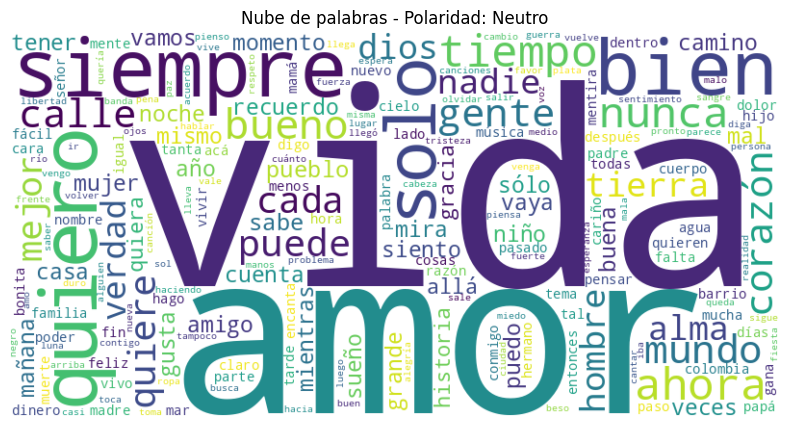

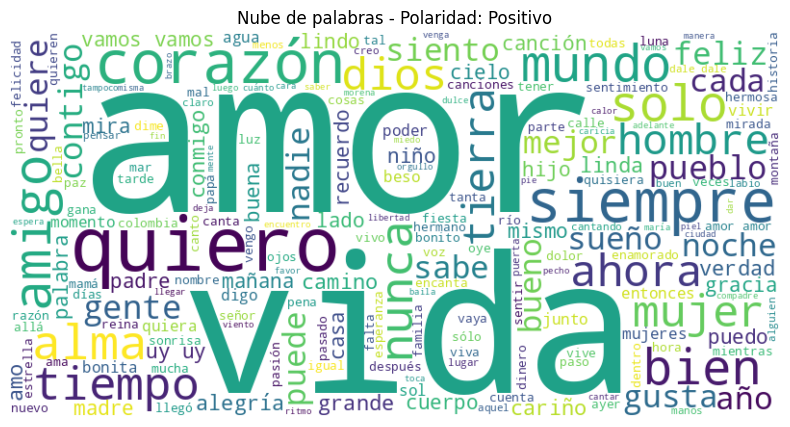

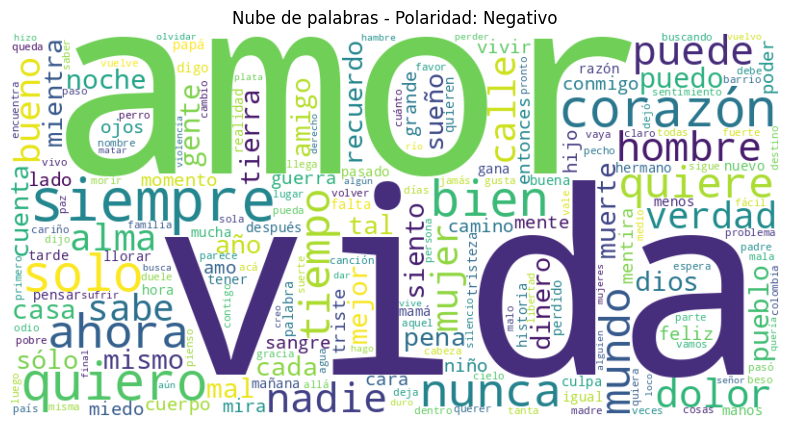

In [ ]:
# Limpiar letras
df["letra_limpia"] = df["LETRA"].apply(limpiar_texto)

# Agrupar por polaridad
polaridades = df["POLARIDAD"].unique()

for polaridad in polaridades:
    texto = " ".join(df[df["POLARIDAD"] == polaridad]["letra_limpia"])

    # Crear nube de palabras
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(texto)

    # Mostrar
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Nube de palabras - Polaridad: {polaridad}")
    plt.show()


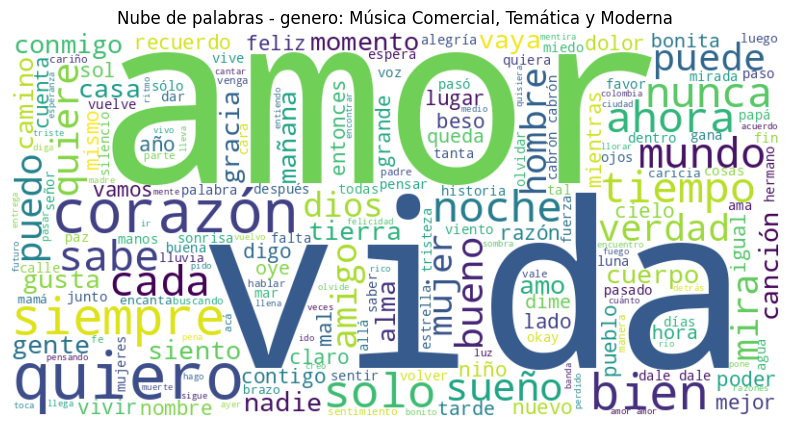

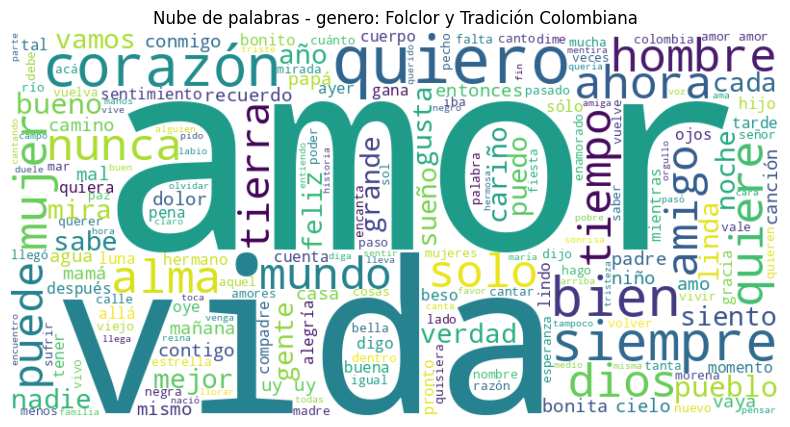

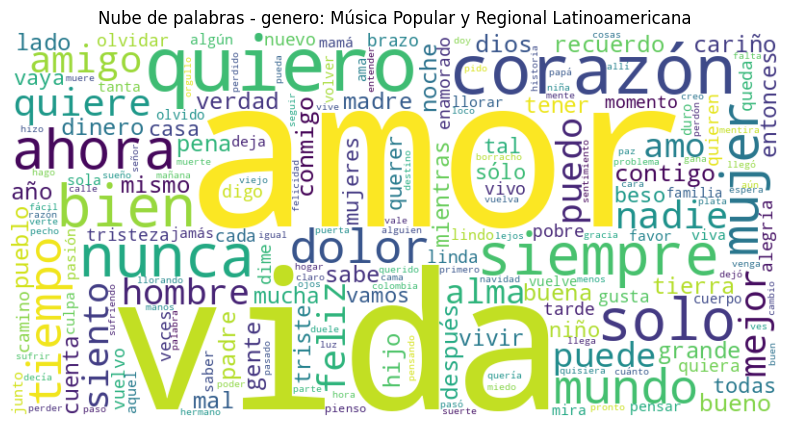

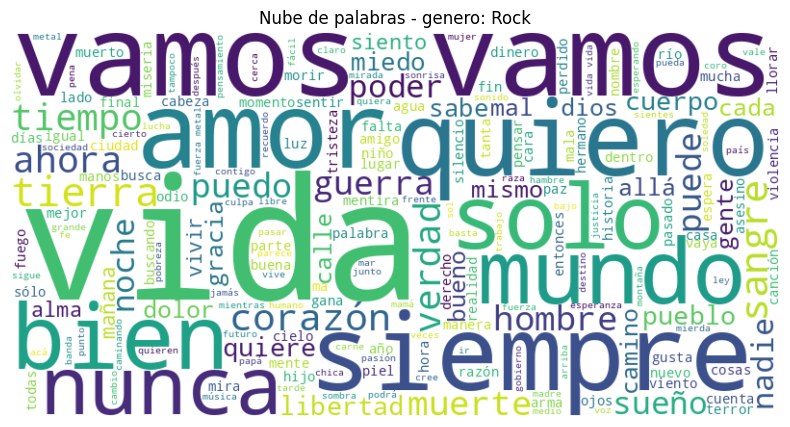

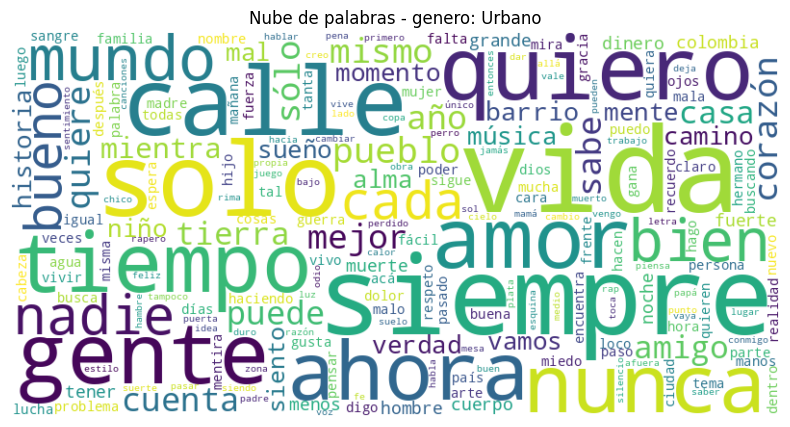

In [ ]:
# Limpiar letras
df["letra_limpia"] = df["LETRA"].apply(limpiar_texto)

# Agrupar por polaridad
generos = df["Genero Definitivo"].unique()

for genero in generos:
    texto = " ".join(df[df["Genero Definitivo"] == genero]["letra_limpia"])

    # Crear nube de palabras
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(texto)

    # Mostrar
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Nube de palabras - genero: {genero}")
    plt.show()

In [ ]:
polaridad_año = df.groupby(['AÑO', 'POLARIDAD']).size().unstack(fill_value=0)

In [ ]:
polaridad_año.index = polaridad_año.index.astype(int)

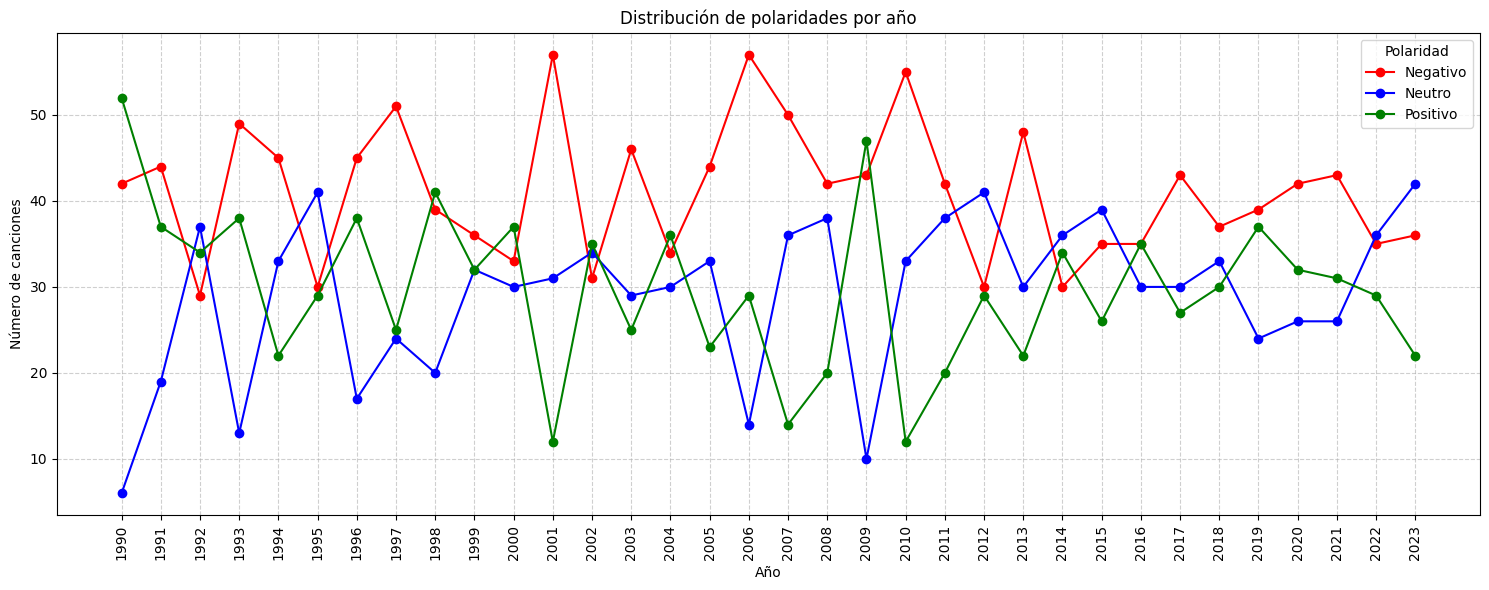

In [ ]:
colores = {
    'Negativo': 'red',
    'Neutro': 'blue',
    'Positivo': 'green'
}

plt.figure(figsize=(15, 6))

for polaridad in polaridad_año.columns:
    plt.plot(
        polaridad_año.index,
        polaridad_año[polaridad],
        label=polaridad,
        marker='o',
        color=colores.get(polaridad, 'gray')
    )

plt.title('Distribución de polaridades por año')
plt.xlabel('Año')
plt.ylabel('Número de canciones')

# Mostrar todos los años de 1990 a 2023
plt.xticks(ticks=range(1990, 2024), rotation=90)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Polaridad')
plt.tight_layout()
plt.show()

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')

# Definir ruta
ruta = "/content/drive/MyDrive/Proyecto de profundización 1/PROYECTO GRADO 2025/Resultados modelos/Base ajustada polaridad.xlsx"

# Exportar a Excel
df.to_excel(ruta, index=False)

print(f"Archivo guardado en: {ruta}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo guardado en: /content/drive/MyDrive/Proyecto de profundización 1/PROYECTO GRADO 2025/Resultados modelos/Base ajustada polaridad.xlsx
